<div style="font-family: -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif; border-bottom: 2px solid #333; padding-bottom: 12px; margin-bottom: 20px;">
    <h1 style="margin: 0 0 6px 0; font-size: 24px; color: #111;">air-quality-corr-disease.ipynb</h1>
    <div style="font-size: 13px; color: #555;">
        <span><strong>Project:</strong> NYC Air Quality Public Health Data Analysis</span> &nbsp;&bull;&nbsp; 
        <span><strong>Author:</strong> Kathryn Penrod</span> &nbsp;&bull;&nbsp; 
        <span><strong>Goal:</strong> How do air quality patterns correlate with disease prevalence or healthcare utilization?</span>
    </div>
</div>

In [1]:
import numpy as np 
import pandas as pd 
import scipy as sp 
from scipy import stats 
import matplotlib 
import sqlite3 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates
import seaborn as sns 
import sklearn 
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA 
import warnings 
import re

data = pd.read_pickle('all_clean_dfs.pkl')
globals().update(data)
all_dfs = data

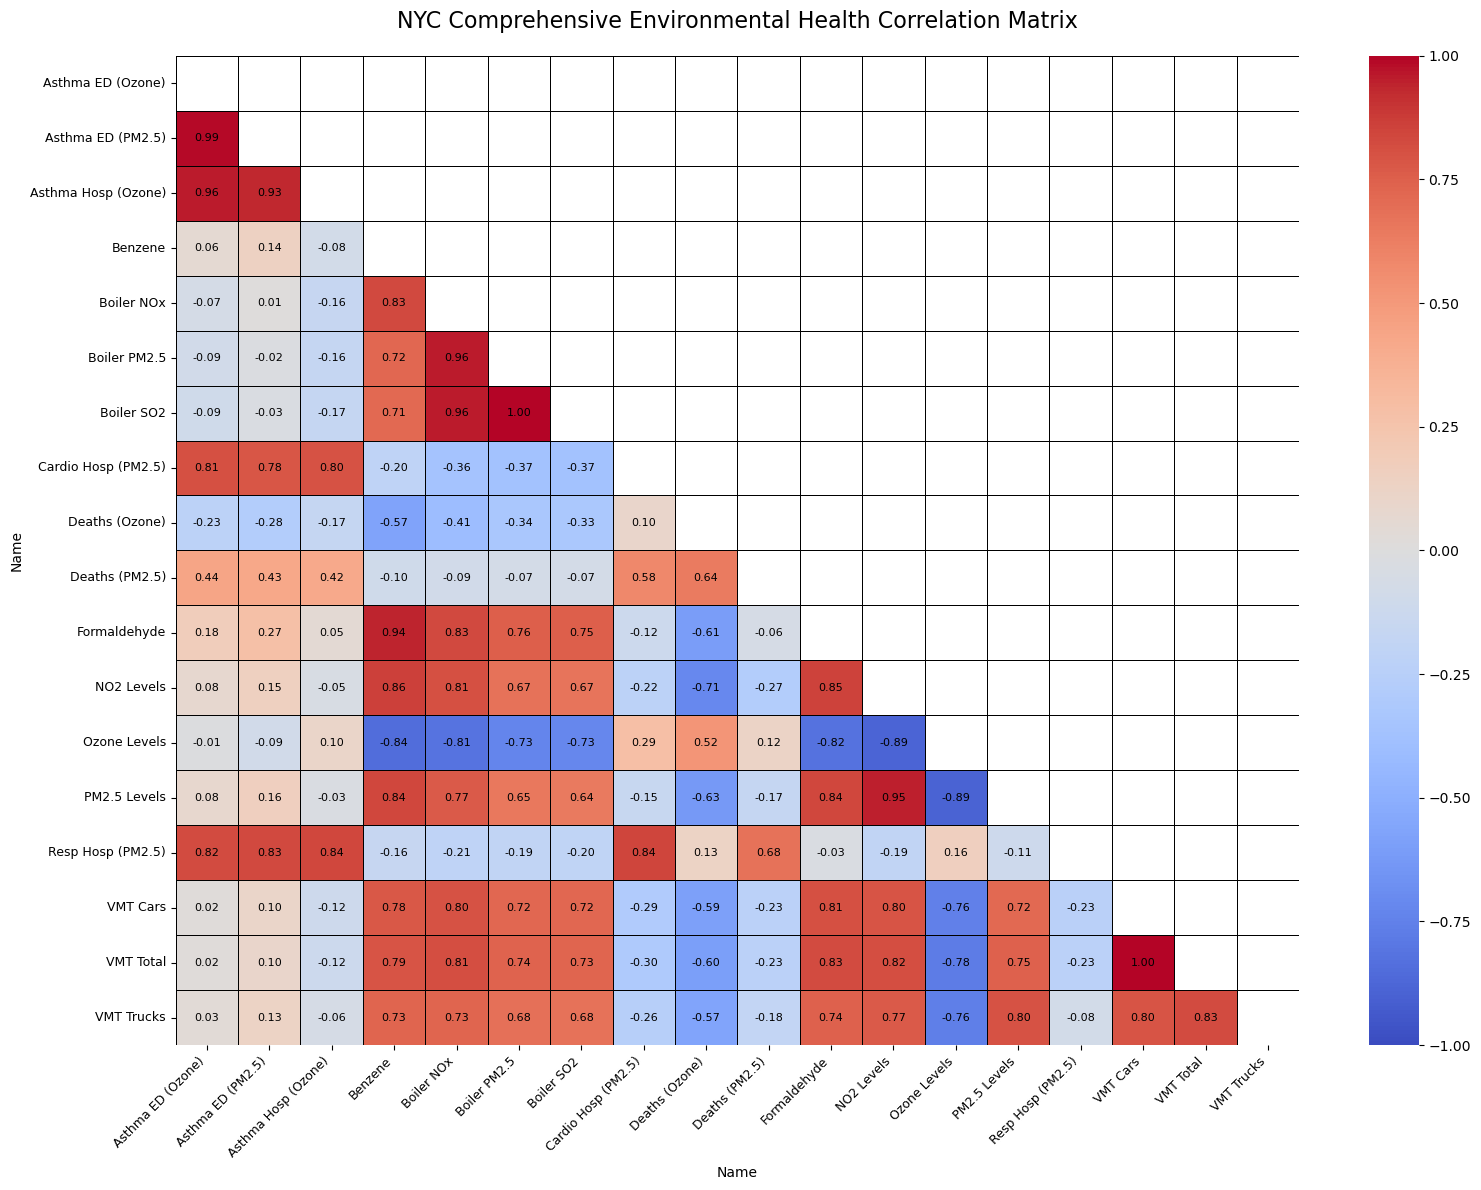

In [2]:
# Comprehensive Environmental Health Correlation Matrix


corr_matrix = pivoted_df.corr() 
mask = np.triu(np.ones_like(corr_matrix, dtype=bool)) 
plt.figure(figsize=(16, 12)) 
sns.heatmap( corr_matrix, mask=mask, cmap='coolwarm', linewidths=0.5, linecolor='black', cbar=True, vmin=-1, vmax=1, annot=True, fmt=".2f", annot_kws={'size': 8, 'color': 'black'} ) 
plt.xticks(rotation=45, ha='right', fontsize=9) 
plt.yticks(rotation=0, fontsize=9) 
plt.title('NYC Comprehensive Environmental Health Correlation Matrix', size=16, pad=20) 
plt.tight_layout() 
plt.show() 

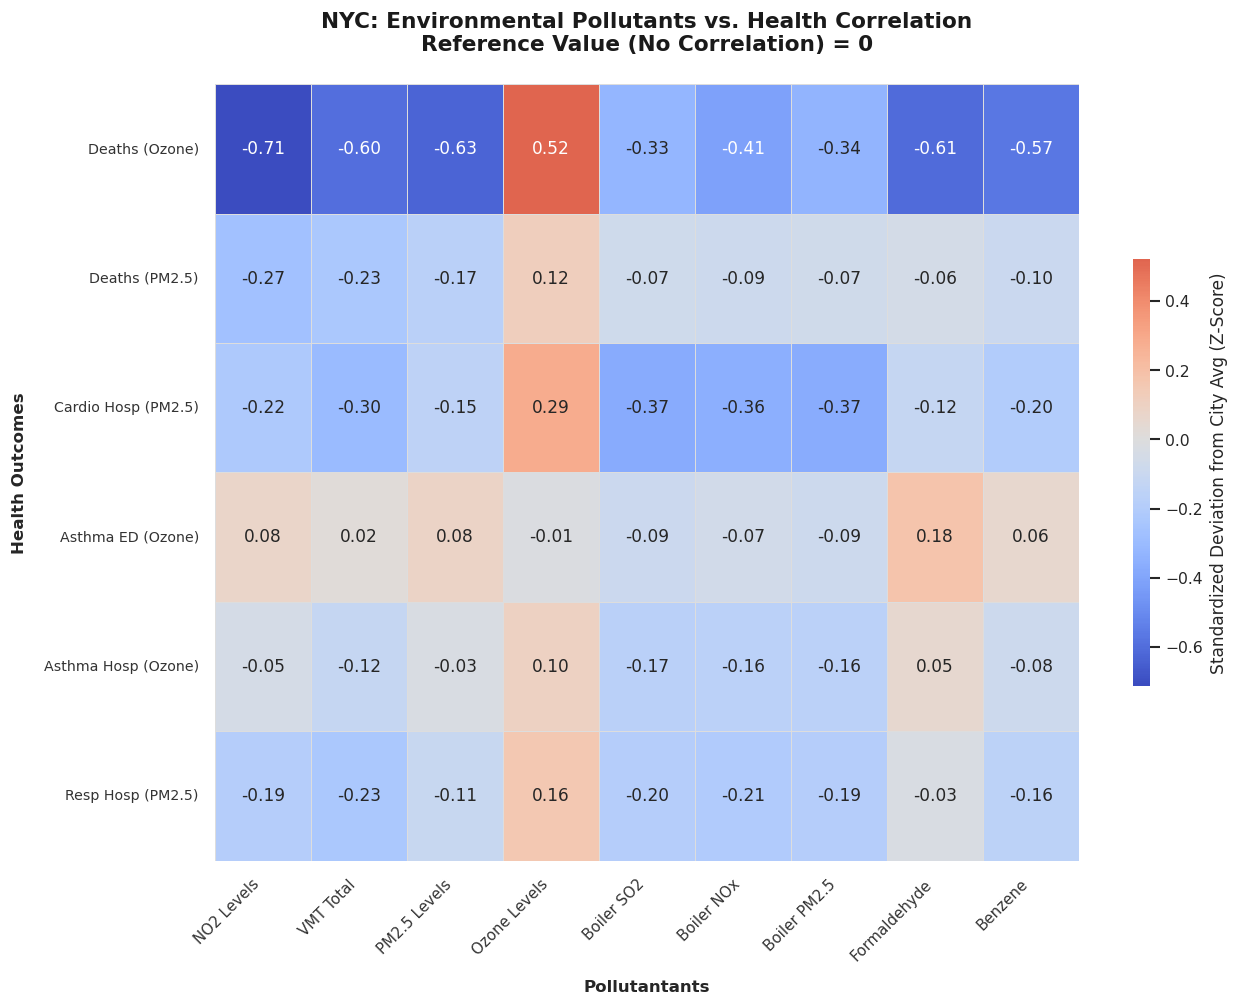

In [3]:
#heatmap of Environmental Pollutants vs. Health Correlation


#variables
pollu_variables = [
    "NO2 Levels",
    "VMT Total",
    "PM2.5 Levels",
    "Ozone Levels",
    "Boiler SO2",
    "Boiler NOx",
    "Boiler PM2.5",
    "Formaldehyde",
    "Benzene",
]
health_variables = [
    'Deaths (Ozone)',
    'Deaths (PM2.5)', 
    'Cardio Hosp (PM2.5)',
    'Asthma ED (Ozone)',
    'Asthma Hosp (Ozone)',
    'Resp Hosp (PM2.5)',
]

# Compute correlation matrix
corr_matrix = pivoted_df.corr().loc[health_variables, pollu_variables]

#Colormap colors
cmap = plt.get_cmap("coolwarm").copy()
cmap.set_bad(color="#EAEAEA")

# Plot Heatmap setup
plt.figure(figsize=(11, 8.5), dpi=120)
sns.set_theme(style="white", font_scale=0.85)

ax = sns.heatmap(
    corr_matrix,
    cmap=cmap,
    center=0,  # 0 = city average ref baseline
    annot=True,  # Include data numbers in box
    fmt=".2f",  # 2 decimal places
    linewidths=0.5,
    linecolor="#DDDDDD",
    cbar_kws={
        "label": "Standardized Deviation from City Avg (Z-Score)",
        "shrink": 0.55,
        "aspect": 26,},)

# Titles & Formatting
plt.title(
    "NYC: Environmental Pollutants vs. Health Correlation\n"
      "Reference Value (No Correlation) = 0",
    fontsize=13,
    fontweight="bold",
    pad=20,
    color="#1A1A1A",
    loc="center",)

plt.xlabel(
"Pollutantants", fontsize=10, fontweight="bold", labelpad=10)
plt.ylabel("Health Outcomes", fontsize=10, fontweight="bold", labelpad=10)

plt.xticks(rotation=45, ha="right", fontsize=9, color="#333333")
plt.yticks(rotation=0, fontsize=8.5, color="#333333")

plt.tight_layout()
plt.show()